In [1]:
import rasterio
import rasterio.mask
import r5py as r5
import h3
import geopandas as gpd
from shapely.geometry import Polygon, box
from pyrosm import OSM
import numpy as np
from pyrosm.data import sources
from pyrosm import get_data
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta
from reusable import *

#### **Paths and Data**

In [2]:
osm_path = 'cities\singapore\Singapore.osm.pbf'
gtfs_path = 'cities\singapore\mdb-3051-202602171452.zip'
pop_path = 'cities\singapore\sgp_general_population_2020.tif'
city_proj = gpd.read_file("cities/singapore/sg_boundary.zip")

In [3]:
tn = r5.TransportNetwork(osm_path, gtfs=gtfs_path)

#### **Boundaries + grid**

In [4]:
osm = OSM(osm_path)
boundaries = osm.get_boundaries()
#boundaries.sort_values(by="admin_level", ascending=True).head(10)

Using local GeoJSON/Shapefile boundary

In [5]:
city_proj = gpd.read_file("cities/singapore/sg_boundary.zip")
city_proj = city_proj.to_crs(city_proj.estimate_utm_crs())
city_proj = city_proj.dissolve()

<Axes: >

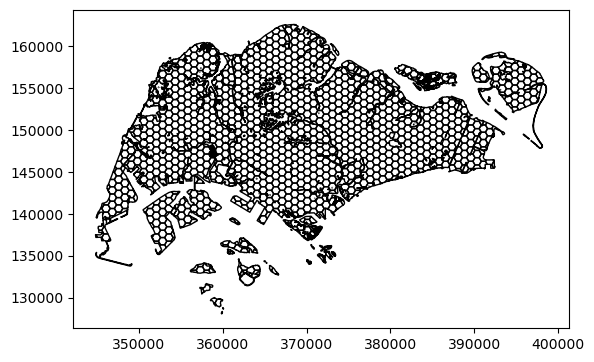

In [6]:
grid = create_hex_grid(city_proj, 500)
grid.plot(edgecolor='black', facecolor='none')

#### **Populating the grid**

Raster total population:  5,826,222
Hex grid total population: 5,818,209
Coverage: 99.9%


d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 9 classes. Setting k to 5.
  self.bins = quantile(y, k=k)


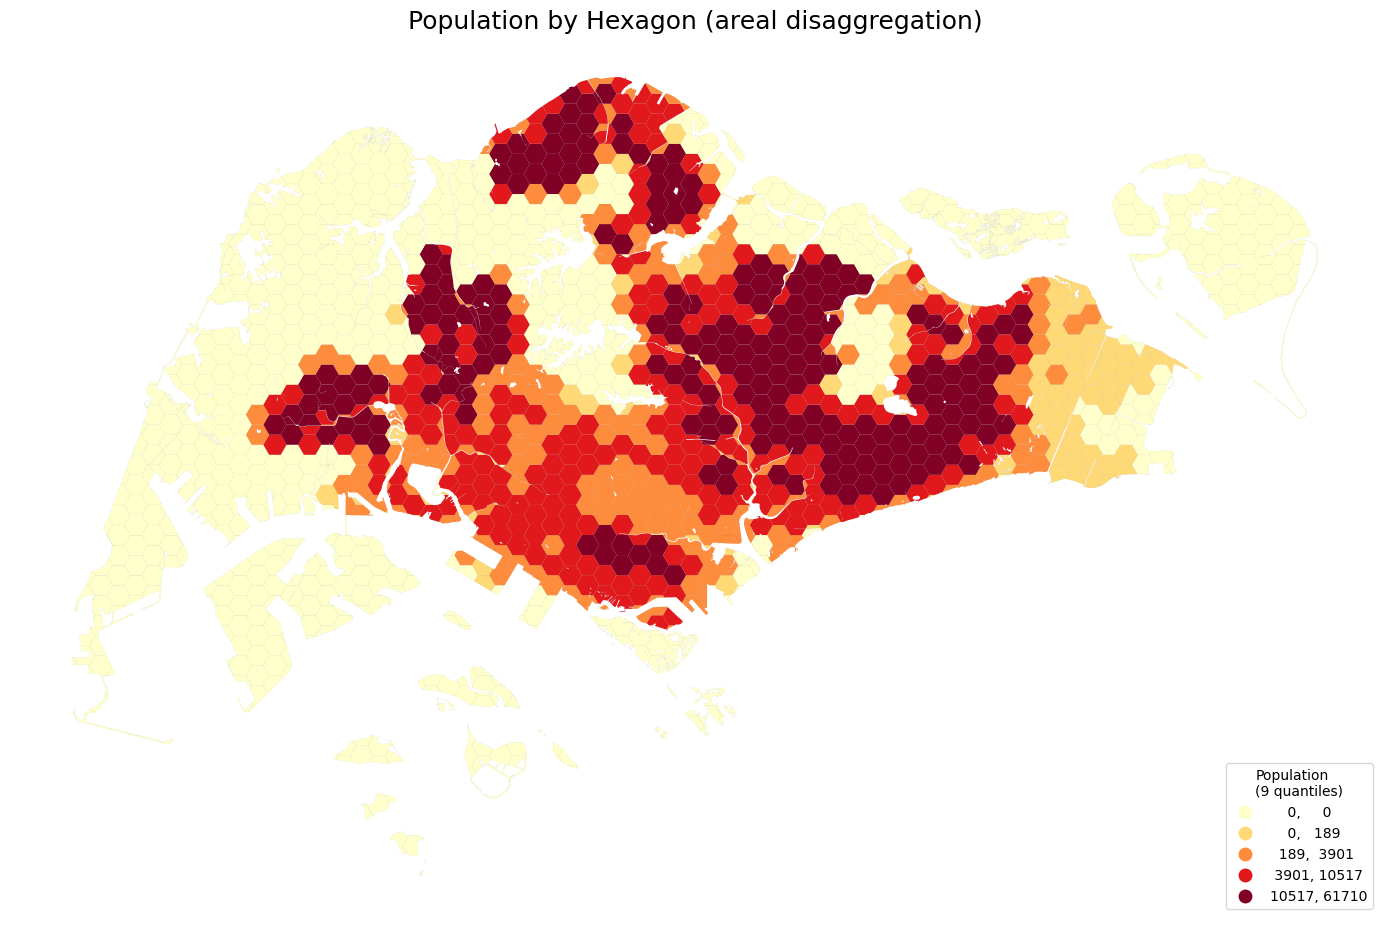

In [7]:
grid_pop = assign_population_to_grid(pop_path, grid, plot=True)

In [8]:
result_geo = build_city_geojson(
    grid=grid,
    grid_pop=grid_pop,
    osm=osm,
    tn=tn,
    output_path="data/singapore_scores.geojson",
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=25,
    beta=0.0277,
    gravity_normalisation=100,
)

City-wide baseline distribution:
  count_community: 0.050
  count_education: 0.051
  count_essential_services: 0.110
  count_food_and_drink: 0.642
  count_healthcare: 0.076
  count_shelter: 0.071


#### **Origins**

In [ ]:
origins = create_origins(grid, grid_pop)
origins.head(5)

#### **Destinations (POIs)**

In [ ]:
destinations = create_POIs(osm, summary=True)

#### **Finally testing :DD**

In [ ]:
categories = ['food_and_drink','shelter','essential_services','education','healthcare','community']

In [ ]:
essentials = destinations[destinations['amenity class'].isin(categories)]

In [ ]:
travel_time_matrix = r5.TravelTimeMatrix(
    tn,
    origins=origins,
    destinations=essentials,
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=timedelta(minutes=25) #CUTOFF
)

In [ ]:
min_tt_wide = min_travel_time(travel_time_matrix, essentials)
min_tt_wide.head(10)

#### **Exponential Decay**

In [ ]:
# examples
for cutoff in [10, 15, 20, 25]:
    b = suggested_beta(cutoff)
    print(f"cutoff={cutoff}min, 50% weight retained → β = {b:.4f}")


In [ ]:
def plot_decay_curves(betas, max_time=60, cutoff_line=30, target_weight=0.5):
    t = np.linspace(0, max_time, 300)

    fig, ax = plt.subplots(figsize=(10, 5))
    for beta in betas:
        ax.plot(t, np.exp(-beta * t), label=f"β = {beta}", linewidth=2)

    ax.axvline(cutoff_line, color="grey", linestyle="--", alpha=0.6,
               label=f"{cutoff_line} min reference")
    ax.axhline(target_weight, color="black", linestyle=":", alpha=0.4,
               label=f"{int(target_weight * 100)}% weight")

    ax.set_xlabel("Travel Time (minutes)", fontsize=12)
    ax.set_ylabel("Weight (contribution to score)", fontsize=12)
    ax.set_title("Exponential Decay: Weight vs. Travel Time", fontsize=14)
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

for cutoff in [25]:
    b = suggested_beta(cutoff, target_weight=0.2)
    print(f"cutoff={cutoff}min, 50% weight retained → β = {b:.4f}")
    plot_decay_curves(betas=[b], cutoff_line=cutoff, target_weight=0.2)


In [ ]:
no_gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0)

In [ ]:
gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0.0644)
gravity.head(5)

### **Adjusting for Population**

In [ ]:
pop_weighed = weight_pop(gravity, origins, score_cols=["gravity_food_and_drink"], normalisation=1000)

### **Result Plotting**

In [ ]:
gravity = merge_geometry(gravity, grid=grid)

In [ ]:
res = merge_geometry(min_tt_wide, grid)

In [ ]:
pop_weighed = merge_geometry(pop_weighed, grid)

In [ ]:
cols = [x for x in no_gravity.columns if x not in ['from_id','avg_gravity']]
diversity = compute_diversity_scores(no_gravity, count_cols=cols)

In [ ]:
no_gravity = merge_geometry(no_gravity, grid=grid)
diversity = merge_geometry(diversity, grid=grid)

In [ ]:
def plot_hex_score(results_geo, score_col, from_id_col="from_id", scheme="Quantiles",
                   k=9, cmap="viridis", title=None, figsize=(14, 12),
                   legend_fmt="{:.1f}", ax=None, show=True):

    n_missing = results_geo[score_col].isna().sum()
    if n_missing > 0:
        print(f"Note: {n_missing} hexes have NaN for '{score_col}' and will appear grey.")

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)

    results_geo.plot(
        column=score_col,
        cmap=cmap,
        scheme=scheme,
        k=k,
        legend=True,
        linewidth=0.02,
        edgecolor="none",
        missing_kwds={"color": "lightgrey", "label": "No data"},
        legend_kwds={
            "loc": "upper left",
            "bbox_to_anchor": (1.02, 1),
            "fmt": legend_fmt
        },
        ax=ax
    )

    ax.set_title(title if title else score_col.replace("_", " ").title(), fontsize=18)
    ax.set_axis_off()

    if show:
        plt.tight_layout()
        plt.show()

In [ ]:
fig = plt.figure(figsize=(18, 26))
gs = fig.add_gridspec(
    nrows=8, ncols=2,
    height_ratios=[12, 1, 12, 1, 12, 1, 12, 1],
    hspace=0.35, wspace=0.15
)

plots = [
    (no_gravity, "gravity_food_and_drink", "Basic counts", "Oranges", "Quantiles", 20),
    (gravity, "gravity_food_and_drink", "Gravity weighted", "Oranges", "Quantiles", 20),
    (res, "min_tt_food_and_drink", "Minimum travel time", "viridis", "Quantiles", 20),
    (res, "n_unreachable_categories", "Unreachable categories", "Reds", "EqualInterval", 6),
    (res, "avg_tt", "Average travel time", "viridis", "NaturalBreaks", 7),
    (pop_weighed, "gravity_food_and_drink_per_1000", "Pop-weighted gravity", "Oranges", "Quantiles", 20),
    (diversity, "city_similarity", "Diversity", "Oranges", "Quantiles", 20),
]

for i, (gdf, col, ttl, cmap, scheme, k) in enumerate(plots):
    row = (i // 2) * 2
    col_idx = i % 2

    ax = fig.add_subplot(gs[row, col_idx])

    plot_hex_score(
        gdf,
        score_col=col,
        cmap=cmap,
        scheme=scheme,
        k=k,
        title=ttl,
        ax=ax,
        show=False
    )

if len(plots) % 2 == 1:
    fig.add_subplot(gs[6, 1]).axis("off")
    fig.add_subplot(gs[7, 1]).axis("off")

plt.tight_layout()
fig.savefig("singapore_results.png", dpi=300, bbox_inches="tight")